## Poner los paquetes usados aqui

In [ ]:
%%writefile requirements.txt

pandas
numpy
matplotlib
seaborn
plotly
nbformat
ipywidgets

Overwriting requirements.txt


In [6]:
# Install a pip package in the current Jupyter kernel
import sys
!{sys.executable} -m pip install -r requirements.txt

In [1]:
# Importamos las librerias
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import seaborn as sns

from IPython.display import display

### Vamos a visualizar los datos!!

In [2]:
data = pd.read_csv("data/healthcare_tp.csv")

display(data.head())
display(data.tail())


,Age,Gender,Blood Type,Medical Condition,Date of Admission,Discharge Date,Admission Type,Billing Amount,Medication,Test Results,Insurance Provider,Insurance Plan
0,56,Female,A+,Hypertension,2023-07-13,2023-07-16,Emergency,5374.88,Aspirin,Abnormal,Aetna,Gold
1,38,Male,A+,Obesity,2024-01-25,2024-02-06,Elective,1986.98,Orlistat,Abnormal,Cigna,Gold
2,56,Male,A+,Asthma,2024-07-30,2024-08-02,Emergency,6086.36,Inhaler,Abnormal,Blue Cross,Gold
3,42,Female,A+,Diabetes,2023-03-29,2023-04-06,Emergency,3589.38,Metformin,Abnormal,Aetna,Gold
4,54,Male,O+,Diabetes,2023-11-03,2023-11-13,Elective,2600.54,Insulin,Inconclusive,Aetna,Basic


,Age,Gender,Blood Type,Medical Condition,Date of Admission,Discharge Date,Admission Type,Billing Amount,Medication,Test Results,Insurance Provider,Insurance Plan
5995,44,Female,A+,Healthy,2024-08-21,2024-08-31,Emergency,3788.63,NaN,Normal,Medicare,Gold
5996,55,Male,O-,Obesity,2023-06-22,2023-06-29,Elective,2831.81,Orlistat,Normal,Cigna,Silver
5997,64,Female,A+,Diabetes,2024-01-07,2024-01-14,Elective,2588.33,Metformin,Inconclusive,Blue Cross,Platinum
5998,13,Female,O+,Obesity,2023-11-09,2023-11-20,Elective,1523.96,Orlistat,Abnormal,Cigna,Silver
5999,75,Male,B+,Hypertension,2023-08-10,2023-08-19,Elective,3736.62,Aspirin,Abnormal,Medicare,Gold


### Proporcion Hombres vs Mujeres

In [9]:
# hay que normalizar los datos antes de hacer la estadistica
data["Gender"] = data["Gender"].str.strip().str.lower()

# Conteo de hombres y mujeres
conteo_genero = (
    data["Gender"]
    .value_counts()
    .reset_index()
)
conteo_genero.columns = ["Gender", "Cantidad"]

# Pie chart interactivo
fig = px.pie(
    conteo_genero,
    names="Gender",
    values="Cantidad",
    title="Distribución por género",
    hole=0.4  # opcional: dona
)

fig.update_traces(textposition="inside", textinfo="percent+label")
fig.show()


### Edad por genero

Me parece medio raro los pibitos de entre 0 a 1 año tienen obesidad, hipertension y cancer. Re mala leche los bebes

In [14]:
bins = np.arange(0, 101, 5)
labels = [f"{bins[i]}-{bins[i+1]-1}" for i in range(len(bins) - 1)]

piramide = data[["Age", "Gender"]].copy()
piramide["Gender"] = piramide["Gender"].astype(str).str.strip().str.lower()
piramide = piramide[piramide["Gender"].isin(["male", "female"])]
piramide["Grupo_Edad"] = pd.cut(
    piramide["Age"],
    bins=bins,
    right=False,
    labels=labels,
    include_lowest=True
)

conteo_piramide = (
    piramide.groupby(["Grupo_Edad", "Gender"], as_index=False)
    .size()
    .rename(columns={"size": "Cantidad"})
)
conteo_piramide["Cantidad_Mostrada"] = np.where(
    conteo_piramide["Gender"] == "male",
    -conteo_piramide["Cantidad"],
    conteo_piramide["Cantidad"]
)

fig = px.bar(
    conteo_piramide,
    x="Cantidad_Mostrada",
    y="Grupo_Edad",
    color="Gender",
    orientation="h",
    category_orders={"Grupo_Edad": labels[::-1]},
    title="Piramide poblacional",
    labels={"Cantidad_Mostrada": "Cantidad", "Grupo_Edad": "Grupo de edad", "Gender": "Genero"},
    hover_data={"Cantidad": True, "Cantidad_Mostrada": False}
)

max_abs = int(conteo_piramide["Cantidad"].max())
tick_vals = np.arange(-max_abs, max_abs + 1, max(1, max_abs // 4))
fig.update_xaxes(tickvals=tick_vals, ticktext=[str(abs(v)) for v in tick_vals])
fig.update_layout(template="plotly_white", bargap=0.08)
fig.show()

display(data[data["Age"] == 0])

,Age,Gender,Blood Type,Medical Condition,Date of Admission,Discharge Date,Admission Type,Billing Amount,Medication,Test Results,Insurance Provider,Insurance Plan,Duration
113,0,Male,B+,Healthy,2024-08-10,2024-08-23,Elective,1187.43,NaN,Normal,Cigna,Platinum,13
369,0,Female,AB-,Obesity,2023-10-24,2023-11-06,Elective,1908.80,Orlistat,Inconclusive,Blue Cross,Gold,13
378,0,Male,AB-,Obesity,2023-08-23,2023-08-31,Emergency,2246.41,Paracetamol,Inconclusive,Blue Cross,Gold,8
585,0,Male,AB-,Hypertension,2023-09-18,2023-09-23,Emergency,2443.35,Aspirin,Abnormal,Blue Cross,Gold,5
674,0,Female,O+,Healthy,2023-06-04,2023-06-12,Emergency,3147.61,NaN,Abnormal,Cigna,Gold,8
743,0,Male,A+,Hypertension,2023-02-18,2023-02-27,Elective,1398.92,Beta Blocker,Abnormal,Blue Cross,Silver,9
991,0,Male,AB-,Hypertension,2024-06-13,2024-06-23,Emergency,2507.04,Aspirin,Abnormal,Blue Cross,Silver,10
1460,0,Male,O+,Healthy,2024-11-18,2024-11-25,Elective,1687.24,NaN,Normal,Blue Cross,Platinum,7
1701,0,Male,A+,Hypertension,2023-02-11,2023-02-21,Elective,1233.38,Aspirin,Inconclusive,Blue Cross,Basic,10
1800,0,Female,B-,Obesity,2023-02-28,2023-03-03,Emergency,3348.29,Paracetamol,Normal,Medicare,Silver,3


### Drivers del gasto

Podemos ver que la mayor cantidad de gastos se hacen en emergencias

In [7]:
fig_admision = px.box(
    data,
    x="Admission Type",
    y="Billing Amount",
    color="Admission Type",
    points="outliers",
    title="Distribución de costos por tipo de admisión"
)
fig_admision.update_layout(template="plotly_white", showlegend=False)
fig_admision.show()


# fig_patologia = px.box(
#     data,
#     x="Medical Condition",
#     y="Billing Amount",
#     color="Medical Condition",
#     facet_col="Admission Type",
#     points=False,
#     title="Distribución de costos por patología, separado por tipo de admisión"
# )
# fig_patologia.update_layout(template="plotly_white", showlegend=False)
# fig_patologia.update_xaxes(tickangle=45)
# fig_patologia.show()

### Edad vs duración (eficiencia operativa)

In [8]:
# Convertimos las columnas al formato datetime de pandas
data["Date of Admission"] = pd.to_datetime(data["Date of Admission"], errors="coerce")
data["Discharge Date"] = pd.to_datetime(data["Discharge Date"], errors="coerce")

# Creamos la columna restando: Alta menos Admision
data["Duration"] = (data["Discharge Date"] - data["Date of Admission"]).dt.days

# Filtramos nulos para un grafico mas limpio
data_duracion = data.dropna(subset=["Age", "Duration", "Admission Type"]).copy()

fig = px.scatter(
    data_duracion,
    x="Age",
    y="Duration",
    color="Admission Type",
    symbol="Admission Type",
    opacity=0.65,
    hover_data=["Medical Condition", "Billing Amount", "Insurance Provider"],
    title="Edad vs duracion de internacion"
)

fig.update_traces(marker=dict(size=9, line=dict(width=0.6, color="white")))
fig.update_layout(
    template="plotly_white",
    legend_title_text="Tipo de admision",
    xaxis_title="Edad",
    yaxis_title="Duracion (dias)"
)
fig.show()

### Pertinencia Médica

La idea es responder:
 
**¿Los medicamentos se adaptan a la condición?**

Cortesia de gemini

1. Análisis por Condición
- Hypertension: Reciben Aspirin y Beta Blocker. Es correcto. Los beta-bloqueantes son un tratamiento estándar para controlar la presión arterial, y la aspirina se usa frecuentemente como preventivo cardiovascular en estos pacientes.
- Diabetes: Reciben Insulin y Metformin. Es totalmente coherente. Son los dos pilares del tratamiento para regular los niveles de glucosa en sangre.
- Asthma: Reciben Corticosteroid e Inhaler. Es correcto. Los inhaladores proporcionan alivio rápido o mantenimiento, y los corticosteroides tratan la inflamación crónica de las vías respiratorias.
- Cáncer: Reciben Chemotherapy e Immunotherapy. Es adecuado. Son tratamientos oncológicos estándar para atacar células tumorales y fortalecer el sistema inmune.
- Obesidad: Reciben Orlistat y Paracetamol. Aquí hay un punto a observar:
    - Orlistat: Es un medicamento específico para la pérdida de peso, por lo que es correcto.
    - Paracetamol: No trata la obesidad en sí. Sin embargo, en la vida real, se asocia frecuentemente a pacientes con obesidad para tratar dolores articulares o de espalda derivados del exceso de peso.
2. Conclusiones para tu Análisis Exploratorio (EDA)
- Alta Coherencia Clínica: El gráfico muestra bloques muy limpios. Esto indica que en tu dataset no hay errores groseros de carga (como un asmático recibiendo quimioterapia). La práctica médica registrada es consistente con los diagnósticos.
- Foco en el Volumen: Las celdas más oscuras (Hipertensión y Obesidad) coinciden con las enfermedades que mencionaste que generan más gasto total. Hay más pacientes en estos grupos, por lo que se consume más medicación.
- Oportunidad de Gestión: Al ver que los tratamientos están tan estandarizados, el problema de la prepaga no parece ser la "mala praxis", sino la alta prevalencia de crónicos. La recomendación ingenieril sería intervenir en la prevención de la obesidad y la hipertensión para reducir la necesidad de estas recetas a largo plazo

In [9]:
# Tabla cruzada
med_condition_medication = pd.crosstab(
    data["Medical Condition"],
    data["Medication"]
)

fig = px.imshow(
    med_condition_medication,
    color_continuous_scale="Blues",
    aspect="auto",
    labels={"x": "Medicacion", "y": "Condicion medica", "color": "Cantidad"},
    title="Relacion entre condicion medica y medicacion"
)

fig.update_xaxes(side="bottom")
fig.update_layout(template="plotly_white")
fig.show()

### Resultados de tests (prevención vs reacción)

Muchos "Abnormal" → sistema reactivo, no preventivo

In [25]:
conteo_tests = (
    data["Test Results"]
    .astype(str)
    .str.strip()
    .value_counts()
    .reset_index()
)
conteo_tests.columns = ["Test Results", "Cantidad"]

fig = px.bar(
    conteo_tests,
    x="Test Results",
    y="Cantidad",
    color="Test Results",
    title="Distribución de resultados de tests",
    labels={"Test Results": "Resultado", "Cantidad": "Cantidad"},
    text_auto=True
)

fig.update_layout(template="plotly_white", showlegend=False)
fig.show()

### Duración vs costo (eficiencia hospitalaria)

ver si este grafico vale la pena o no el analisis, esto mide en cuanto se despacha gente

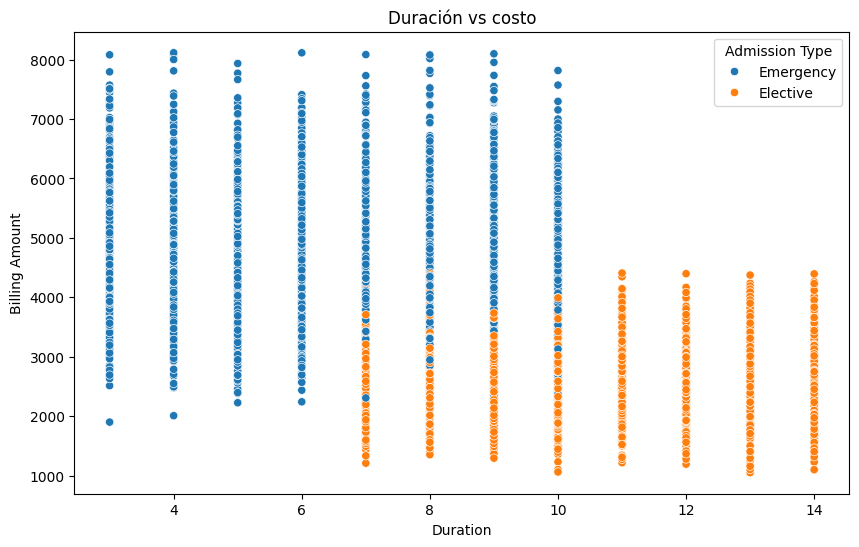

In [19]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=data, x='Duration', y='Billing Amount', hue='Admission Type')
plt.title("Duración vs costo")
plt.show()

### Edad vs Gastos

Se puede ver que a medida que aumenta la edad aumentan los gastos minimos(?).

Parece que conviene tener gente joven en la prepaga, lo cual es algo real

In [30]:
fig = px.scatter(
    data,
    x="Age",
    y="Billing Amount",
    opacity=0.7,
    title="Edad vs gastos por género",
    labels={"Age": "Edad", "Billing Amount": "Gastos", "Gender": "Género"},
    hover_data=["Medical Condition", "Admission Type", "Insurance Provider"]
)

fig.update_layout(template="plotly_white")
fig.show()

### Tipo de sangre de nuestra muestra

Parece ser real comparado con la realidad, parece real

In [21]:
conteo_sangre = (
    data["Blood Type"]
    .astype(str)
    .str.strip()
    .value_counts()
    .reset_index()
)
conteo_sangre.columns = ["Blood Type", "Cantidad"]

fig = px.pie(
    conteo_sangre,
    names="Blood Type",
    values="Cantidad",
    title="Distribución por tipo de sangre",
    hole=0.35
)

fig.update_traces(textposition="inside", textinfo="percent+label")
fig.update_layout(template="plotly_white")
fig.show()

### Gastos por plan

bueno acá es medio joda, parece que a la prepaga no le conviene mucho tener un plan básico ya que gastan lo mismo que todos.

In [26]:
gastos_plan_provider = (
    data.groupby(["Insurance Plan", "Insurance Provider"], as_index=False)["Billing Amount"]
    .sum()
)

orden_planes = (
    gastos_plan_provider.groupby("Insurance Plan", as_index=False)["Billing Amount"]
    .sum()
    .sort_values("Billing Amount", ascending=False)["Insurance Plan"]
)

fig = px.bar(
    gastos_plan_provider,
    x="Insurance Plan",
    y="Billing Amount",
    color="Insurance Provider",
    category_orders={"Insurance Plan": orden_planes.tolist()},
    title="Gasto total por plan, dividido por provider",
    labels={
        "Insurance Plan": "Plan",
        "Billing Amount": "Gasto total",
        "Insurance Provider": "Provider"
    }
)

fig.update_layout(template="plotly_white", barmode="stack")
fig.show()

### Cuantos clientes hay por provider

Acá nos damos cuenta que los provider son casi proporcionales

In [29]:
conteo_provider = (
    data["Insurance Provider"]
    .astype(str)
    .str.strip()
    .value_counts()
    .reset_index()
)
conteo_provider.columns = ["Insurance Provider", "Cantidad"]

fig = px.pie(
    conteo_provider,
    names="Insurance Provider",
    values="Cantidad",
    title="Cantidad de clientes por provider",
    hole=0.35
)

fig.update_traces(textposition="inside", textinfo="percent+label")
fig.update_layout(template="plotly_white")
fig.show()

### Gastos y cantidad por enfermedad tomando como muestra la edad

Podemos ver que en cualquier intervalo que tomes la obesidad es la que más gastos genera y más gente afectada hay

Esto responde:\
**¿Pueden identificar diferencias en los montos de Billing en función de la edad o la condición médica de los asociados?**

In [4]:
import ipywidgets as widgets

edad_min = int(data["Age"].min())
edad_max = int(data["Age"].max())

rango_edad = widgets.IntRangeSlider(
    value=[edad_min, edad_max],
    min=edad_min,
    max=edad_max,
    step=1,
    description="Edad:",
    continuous_update=False
)

salida_gastos = widgets.Output()
salida_cantidad = widgets.Output()


def actualizar_graficos(change=None):
    min_e, max_e = rango_edad.value
    filtrado = data[data["Age"].between(min_e, max_e)]

    gastos_enfermedad = (
        filtrado.groupby("Medical Condition", as_index=False)["Billing Amount"]
        .sum()
        .sort_values("Billing Amount", ascending=False)
    )

    cantidad_enfermedad = (
        filtrado.groupby("Medical Condition")
        .size()
        .reset_index(name="Cantidad")
        .sort_values("Cantidad", ascending=False)
    )

    with salida_gastos:
        salida_gastos.clear_output(wait=True)
        fig_gastos = px.bar(
            gastos_enfermedad,
            x="Medical Condition",
            y="Billing Amount",
            color="Medical Condition",
            title=f"Gastos por enfermedad (edades entre {min_e} y {max_e} años)",
            labels={
                "Medical Condition": "Enfermedad",
                "Billing Amount": "Gasto total"
            },
            text_auto=".2s"
        )
        fig_gastos.update_layout(template="plotly_white", showlegend=False)
        fig_gastos.show()

    with salida_cantidad:
        salida_cantidad.clear_output(wait=True)
        fig_cantidad = px.bar(
            cantidad_enfermedad,
            x="Medical Condition",
            y="Cantidad",
            color="Medical Condition",
            title=f"Cantidad de personas por enfermedad (edades entre {min_e} y {max_e} años)",
            labels={
                "Medical Condition": "Enfermedad",
                "Cantidad": "Cantidad de personas"
            },
            text_auto=True
        )
        fig_cantidad.update_layout(template="plotly_white", showlegend=False)
        fig_cantidad.show()


rango_edad.observe(actualizar_graficos, names="value")
display(rango_edad, salida_gastos, salida_cantidad)
actualizar_graficos()

IntRangeSlider(value=(0, 95), continuous_update=False, description='Edad:', max=95)

Output()

Output()